# Regression

This notebook tries ten different regression models on the Online News Popularity dataset. The goal is to predict how many shares an article will get based on its metadata (word counts, keywords, sentiment, etc).

We already cleaned and feature-engineered the data in the EDA notebook, so here we just load the processed splits and jump straight into modeling.

In [2]:
# imports and plot settings for the regression comparison
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from threadpoolctl import threadpool_limits

sns.set_theme(style="whitegrid", palette="colorblind")
limits = threadpool_limits(limits=4)
pd.set_option("display.max_colwidth", 120)

## Data

In [3]:
# load the pre-split raw data (before scaling) so the pipeline handles preprocessing
train = pd.read_csv("../processed_datasets/news_train_raw.csv")
test = pd.read_csv("../processed_datasets/news_test_raw.csv")
x_train = train.drop(columns="shares")
y_train = train["shares"]
x_test = test.drop(columns="shares")
y_test = test["shares"]
print("Training:", x_train.shape, "Test:", x_test.shape)

Training: (31715, 30) Test: (7929, 30)


In [4]:
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error

prep = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler())
])
cv = KFold(n_splits=3, shuffle=True, random_state=42)
bins = pd.qcut(y_train, 5, labels=False, duplicates="drop")
x_tune, _, y_tune, _ = train_test_split(
    x_train, y_train, train_size=6000, stratify=bins, random_state=42
)
scoring = "r2"

The search uses 6,000 training rows and three folds to keep runtime reasonable. Each final model uses the full training set. Preprocessing is fitted inside each fold, and the test set is kept out of tuning.

**Why only 6,000 rows for tuning?** Grid search with cross-validation means training each model multiple times. Using a smaller subset keeps it fast while still giving us a rough idea of which hyperparameters work best. The final evaluation always trains on ALL training data.

In [5]:
# sanity check: make sure our pipeline reproduces the same processed features
saved = pd.read_csv("../processed_datasets/news_train.csv").drop(columns="shares")
check = clone(prep).fit_transform(x_train)
assert np.allclose(check, saved.to_numpy(), rtol=1e-7, atol=1e-7)
rows = []
tune_rows = []
fitted = {}
predictions = {}
scores_test = {}

## Common evaluation functions

In [6]:
# tune() runs grid search on the small subset and returns the best pipeline
def tune(name, pipe, grid):
    base = cross_val_score(pipe, x_tune, y_tune, cv=cv, scoring=scoring).mean()
    search = GridSearchCV(pipe, grid, cv=cv, scoring=scoring, n_jobs=1)
    search.fit(x_tune, y_tune)
    row = {"Model": name, "Baseline CV": base, "Tuned CV": search.best_score_,
           "Change": search.best_score_ - base, "Best parameters": search.best_params_}
    tune_rows.append(row)
    display(pd.DataFrame([row]))
    return clone(search.best_estimator_)

In [7]:
# evaluate() trains on full training set and records test metrics
def evaluate(name, pipe):
    start = time.perf_counter()
    pipe.fit(x_train, y_train)
    seconds = time.perf_counter() - start
    pred = pipe.predict(x_test)
    fitted[name] = pipe
    predictions[name] = pred
    row = {"Model": name, "R2": r2_score(y_test, pred),
           "RMSE": root_mean_squared_error(y_test, pred),
           "MAE": mean_absolute_error(y_test, pred), "Fit seconds": seconds}
    rows.append(row)
    display(pd.DataFrame([row]).round(4))

## 1. Linear Regression

This is the baseline. It estimates a linear relationship between the inputs and shares.

In [8]:
from sklearn.linear_model import LinearRegression

lr = Pipeline([("prep", clone(prep)), ("model", LinearRegression())])
evaluate("Linear Regression", lr)

,Model,R2,RMSE,MAE,Fit seconds
0,Linear Regression,0.0192,9876.3649,3029.3152,0.1718


Linear Regression gives a test R2 of 0.0192 and an MAE of 3,029 shares.

An R2 of ~0.02 means the model barely explains the variance in shares. That's not great, but it's a useful baseline. If even simple linear regression can't do much, it tells us the relationship between these features and virality is probably not linear (or that share counts are just really noisy).

In [9]:
names = lr.named_steps["prep"].get_feature_names_out()
coef = pd.Series(lr.named_steps["model"].coef_, index=names)
order = coef.abs().sort_values(ascending=False).index
display(coef.loc[order].head(8).rename("Coefficient"))

self_reference_avg_sharess       760.653915
data_channel_is_entertainment   -735.973964
num_self_hrefs                  -655.352223
kw_avg_avg                       455.232389
num_hrefs                        437.828131
num_videos                       397.732758
data_channel_is_world           -381.934448
data_channel_is_bus             -377.151768
Name: Coefficient, dtype: float64

The bar chart below makes it easier to see which features push shares up (green) and which pull them down (red). Longer bars mean a bigger effect.

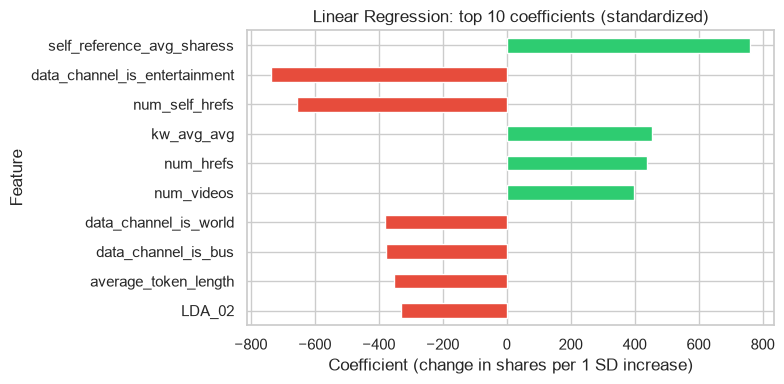

In [10]:
# visualize the top coefficients as a horizontal bar chart
top_coef = coef.loc[order].head(10)
colors = ["#e74c3c" if v < 0 else "#2ecc71" for v in top_coef]
top_coef.plot.barh(figsize=(8, 4), color=colors)
plt.title("Linear Regression: top 10 coefficients (standardized)")
plt.xlabel("Coefficient (change in shares per 1 SD increase)")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Each coefficient gives the change in predicted shares for a one-standard-deviation increase in that input. Correlated inputs can make individual coefficients unstable.

Let's see how the baseline linear model's predictions compare with the actual share counts.

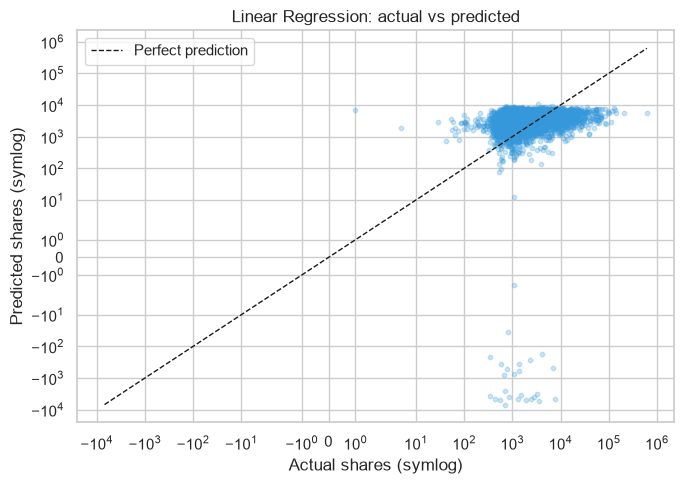

In [11]:
# actual vs predicted scatter for linear regression
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(y_test, predictions["Linear Regression"], alpha=0.25, s=10, color="#3498db")
lims = [min(y_test.min(), predictions["Linear Regression"].min()),
        max(y_test.max(), predictions["Linear Regression"].max())]
ax.plot(lims, lims, "k--", lw=1, label="Perfect prediction")
ax.set(xscale="symlog", yscale="symlog",
       xlabel="Actual shares (symlog)", ylabel="Predicted shares (symlog)",
       title="Linear Regression: actual vs predicted")
ax.legend()
plt.tight_layout()
plt.show()

## 2. Ridge

Ridge shrinks coefficients with an L2 penalty. Alpha controls the amount of shrinkage.

In [12]:
from sklearn.linear_model import Ridge

ridge = Pipeline([("prep", clone(prep)), ("model", Ridge())])
ridge = tune("Ridge", ridge, {"model__alpha": [1, 100, 1000]})
evaluate("Ridge", ridge)

,Model,Baseline CV,Tuned CV,Change,Best parameters
0,Ridge,0.024101,0.024508,0.000407,{'model__alpha': 100}


,Model,R2,RMSE,MAE,Fit seconds
0,Ridge,0.0192,9876.4064,3028.7727,0.2963


Ridge gives a test R2 of 0.0192 and an MAE of 3,029 shares. Tuning changed the mean CV score by +0.00041.

Comparing the top coefficients side by side shows how much (or how little) Ridge shrunk them.

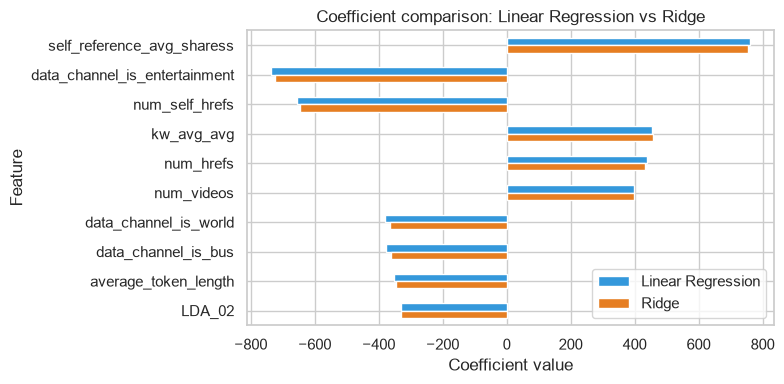

In [13]:
# compare coefficient magnitudes between Linear Regression and Ridge
ridge_coef = pd.Series(ridge.named_steps["model"].coef_, index=names)
compare = pd.DataFrame({"Linear Regression": coef.loc[order].head(10),
                         "Ridge": ridge_coef.loc[order].head(10)})
compare.plot.barh(figsize=(8, 4), color=["#3498db", "#e67e22"])
plt.title("Coefficient comparison: Linear Regression vs Ridge")
plt.xlabel("Coefficient value")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Ridge and Linear Regression give almost identical results here. That makes sense because regularization mostly helps when features are highly correlated or when we're overfitting, and with R2 this low, there isn't much to overfit to begin with.

## 3. Lasso

Lasso uses an L1 penalty and can remove features by setting their coefficients to zero.

In [14]:
from sklearn.linear_model import Lasso

lasso = Pipeline([("prep", clone(prep)), ("model", Lasso(alpha=10, max_iter=30000, tol=0.001))])
lasso = tune("Lasso", lasso, {"model__alpha": [10, 100]})
evaluate("Lasso", lasso)
coef = lasso.named_steps["model"].coef_
print("Zero coefficients:", int(np.isclose(coef, 0).sum()), "of", len(coef))

,Model,Baseline CV,Tuned CV,Change,Best parameters
0,Lasso,0.024606,0.024606,0.0,{'model__alpha': 10}


,Model,R2,RMSE,MAE,Fit seconds
0,Lasso,0.019,9877.4747,3026.6737,0.4834


Zero coefficients: 3 of 30


Lasso gives a test R2 of 0.0190 and an MAE of 3,027 shares. Tuning changed the mean CV score by +0.00000.

Lasso's main selling point is built-in feature selection. Let's see what it kept and what it threw away.

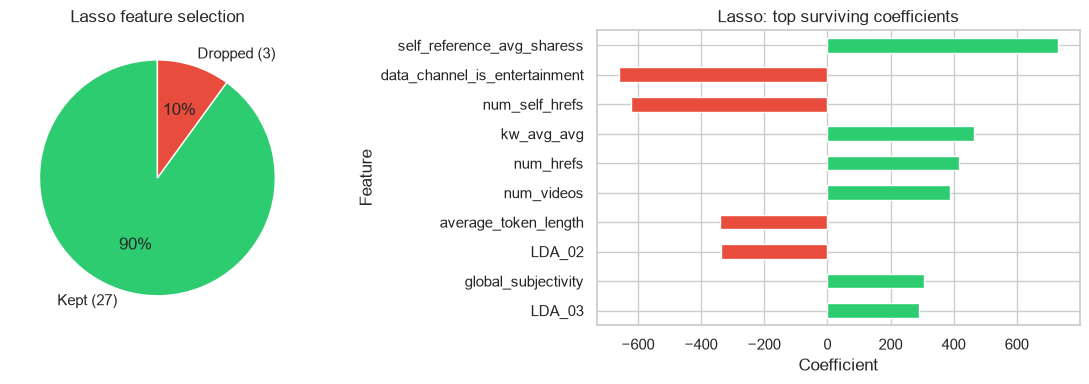

In [15]:
# visualize Lasso feature selection: nonzero vs zero coefficients
lasso_coef = pd.Series(lasso.named_steps["model"].coef_, index=names)
nonzero = (lasso_coef != 0).sum()
zero = (lasso_coef == 0).sum()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# pie chart of kept vs dropped
axes[0].pie([nonzero, zero], labels=[f"Kept ({nonzero})", f"Dropped ({zero})"],
            colors=["#2ecc71", "#e74c3c"], autopct="%1.0f%%", startangle=90)
axes[0].set_title("Lasso feature selection")

# bar chart of surviving coefficients
surviving = lasso_coef[lasso_coef != 0].reindex(lasso_coef.abs().sort_values(ascending=False).index).dropna().head(10)
colors = ["#e74c3c" if v < 0 else "#2ecc71" for v in surviving]
surviving.plot.barh(ax=axes[1], color=colors)
axes[1].set(title="Lasso: top surviving coefficients", xlabel="Coefficient", ylabel="Feature")
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()

Lasso zeroed out a few coefficients, which means it thinks those features add nothing useful for predicting shares. But notice the R2 barely changed. The selected features aren't doing much better than using everything.

## 4. ElasticNet

ElasticNet combines the Ridge and Lasso penalties. The l1_ratio controls their balance.

In [16]:
from sklearn.linear_model import ElasticNet

elastic = Pipeline([("prep", clone(prep)), ("model", ElasticNet(max_iter=30000, tol=0.001))])
grid = {"model__alpha": [0.1, 1], "model__l1_ratio": [0.2, 0.8]}
elastic = tune("ElasticNet", elastic, grid)
evaluate("ElasticNet", elastic)

,Model,Baseline CV,Tuned CV,Change,Best parameters
0,ElasticNet,0.02217,0.024493,0.002323,"{'model__alpha': 0.1, 'model__l1_ratio': 0.2}"


,Model,R2,RMSE,MAE,Fit seconds
0,ElasticNet,0.019,9877.1619,3019.4261,0.5736


ElasticNet gives a test R2 of 0.0190 and an MAE of 3,019 shares. Tuning changed the mean CV score by +0.00232.

Let's overlay all four linear models' predictions on a random sample of test articles to see how similar they are.

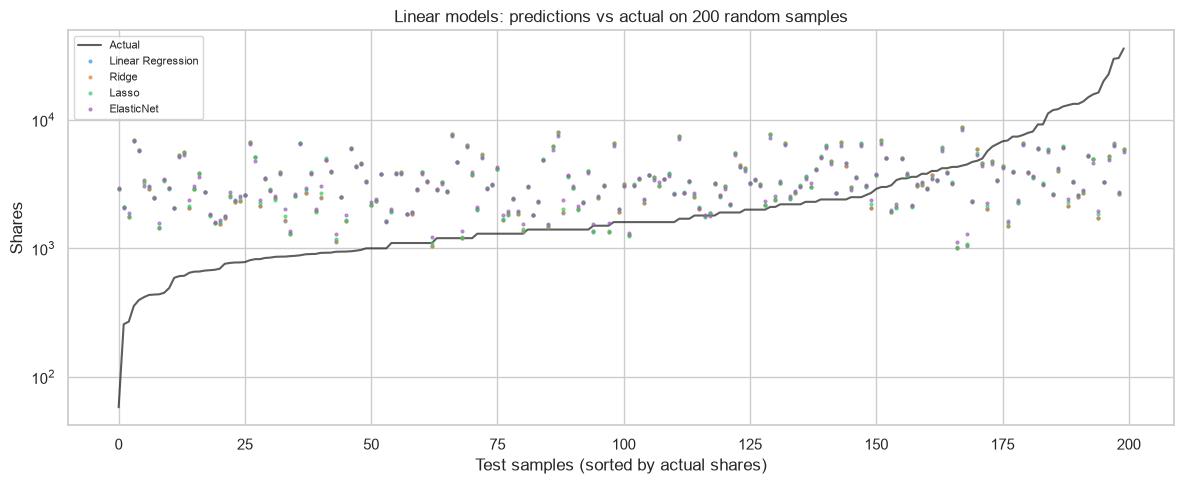

In [17]:
# compare predictions from all four linear models on a random sample
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(y_test), size=200, replace=False)
sample_actual = y_test.to_numpy()[sample_idx]
sort_order = np.argsort(sample_actual)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(sample_actual[sort_order], "k-", lw=1.5, label="Actual", alpha=0.7)
for name, color in [("Linear Regression", "#3498db"), ("Ridge", "#e67e22"),
                     ("Lasso", "#2ecc71"), ("ElasticNet", "#9b59b6")]:
    pred_sample = predictions[name][sample_idx]
    ax.plot(pred_sample[sort_order], ".", ms=4, alpha=0.6, label=name, color=color)
ax.set(xlabel="Test samples (sorted by actual shares)", ylabel="Shares",
       title="Linear models: predictions vs actual on 200 random samples")
ax.set_yscale("symlog")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 5. Polynomial Regression

Degree 2 adds squared terms and interactions. Degrees 1 and 2 are compared on training folds.

In [18]:
from sklearn.preprocessing import PolynomialFeatures

poly = Pipeline([
    ("prep", clone(prep)),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("model", LinearRegression())
])
degree_rows = []
for degree in [1, 2]:
    model = clone(poly).set_params(poly__degree=degree)
    scores = cross_val_score(model, x_tune, y_tune, cv=cv, scoring="r2")
    degree_rows.append({"Degree": degree, "CV R2": scores.mean(), "CV std": scores.std()})
display(pd.DataFrame(degree_rows).round(4))

,Degree,CV R2,CV std
0,1,0.0241,0.0097
1,2,-0.3086,0.1467


Degree 2 is kept in the comparison to show the effect of adding nonlinear terms. Its extra flexibility can also increase overfitting.

In [19]:
evaluate("Polynomial Regression", poly)

,Model,R2,RMSE,MAE,Fit seconds
0,Polynomial Regression,0.0043,9951.1293,3208.5829,2.966


Polynomial Regression gives a test R2 of 0.0043 and an MAE of 3,209 shares.

Side-by-side comparison of linear vs polynomial predictions. Does adding squared terms and interactions actually help?

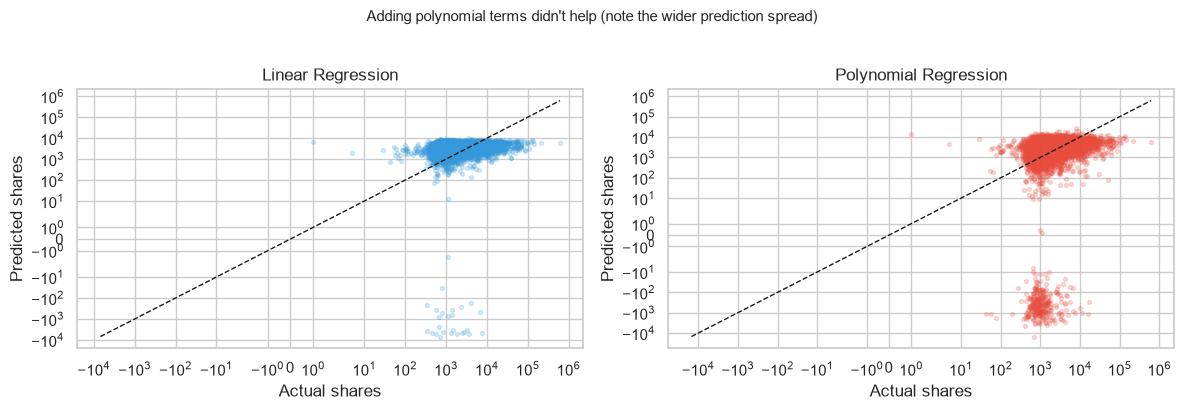

In [20]:
# polynomial vs linear regression predictions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (name, color) in zip(axes, [("Linear Regression", "#3498db"),
                                      ("Polynomial Regression", "#e74c3c")]):
    pred = predictions[name]
    ax.scatter(y_test, pred, alpha=0.2, s=8, color=color)
    lims = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
    ax.plot(lims, lims, "k--", lw=1)
    ax.set(xscale="symlog", yscale="symlog",
           xlabel="Actual shares", ylabel="Predicted shares", title=name)
plt.suptitle("Adding polynomial terms didn't help (note the wider prediction spread)", y=1.02, fontsize=11)
plt.tight_layout()
plt.show()

Polynomial regression actually did worse than plain linear regression. Adding squared terms and interactions created a lot of extra features, and the model probably started fitting noise instead of signal. This is a classic case of the bias-variance tradeoff: more flexibility doesn't always mean better predictions.

## 6. Decision Tree

A tree learns feature thresholds. Limiting its depth reduces overfitting.

In [21]:
from sklearn.tree import DecisionTreeRegressor

tree = Pipeline([("prep", clone(prep)),
                 ("model", DecisionTreeRegressor(max_depth=5, min_samples_leaf=10, random_state=42))])
tree = tune("Decision Tree", tree, {"model__max_depth": [3, 5, 8]})
evaluate("Decision Tree", tree)

,Model,Baseline CV,Tuned CV,Change,Best parameters
0,Decision Tree,-0.058889,-0.049991,0.008898,{'model__max_depth': 3}


,Model,R2,RMSE,MAE,Fit seconds
0,Decision Tree,-0.058,10257.4436,3085.8039,0.6075


Decision Tree gives a test R2 of -0.0580 and an MAE of 3,086 shares. Its squared error is worse than the constant test-mean reference. Tuning changed the mean CV score by +0.00890.

Let's look at how the decision tree's predictions compare with reality and how its errors are distributed.

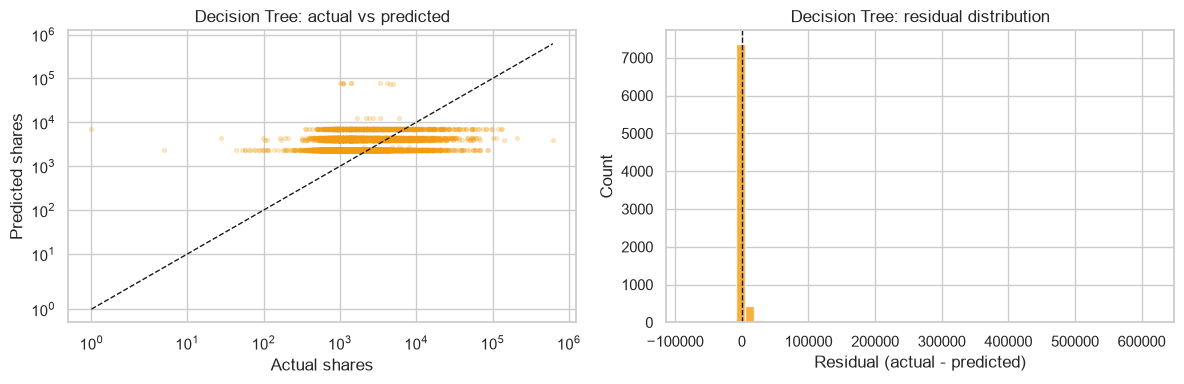

In [22]:
# decision tree: actual vs predicted and residual distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

pred_tree = predictions["Decision Tree"]
axes[0].scatter(y_test, pred_tree, alpha=0.2, s=8, color="#f39c12")
lims = [min(y_test.min(), pred_tree.min()), max(y_test.max(), pred_tree.max())]
axes[0].plot(lims, lims, "k--", lw=1)
axes[0].set(xscale="symlog", yscale="symlog",
            xlabel="Actual shares", ylabel="Predicted shares",
            title="Decision Tree: actual vs predicted")

residual_tree = y_test.to_numpy() - pred_tree
axes[1].hist(residual_tree, bins=50, color="#f39c12", edgecolor="white", alpha=0.8)
axes[1].axvline(0, color="k", ls="--", lw=1)
axes[1].set(xlabel="Residual (actual - predicted)", ylabel="Count",
            title="Decision Tree: residual distribution")
plt.tight_layout()
plt.show()

A negative R2 means the tree is actually doing worse than just predicting the mean for every article. The tree probably memorized some training patterns that don't generalize. Even with depth limits, the noisy target makes it hard for a tree to find reliable splits.

## 7. Random Forest

Random Forest averages several trees. The search compares two forest sizes.

In [23]:
from sklearn.ensemble import RandomForestRegressor

rf = Pipeline([("prep", clone(prep)),
               ("model", RandomForestRegressor(n_estimators=100, max_depth=12,
                                                min_samples_leaf=5, n_jobs=2, random_state=42))])
rf = tune("Random Forest", rf, {"model__n_estimators": [100, 150]})
evaluate("Random Forest", rf)

,Model,Baseline CV,Tuned CV,Change,Best parameters
0,Random Forest,-0.016534,-0.013281,0.003253,{'model__n_estimators': 150}


,Model,R2,RMSE,MAE,Fit seconds
0,Random Forest,-0.0276,10109.4053,3055.3534,70.9719


Random Forest gives a test R2 of -0.0276 and an MAE of 3,055 shares. Its squared error is worse than the constant test-mean reference. Tuning changed the mean CV score by +0.00325.

You'd expect Random Forest to do better than a single tree since it averages out individual errors. But even the forest has a negative R2. When the underlying signal is this weak, averaging noisy predictions doesn't magically create a good prediction.

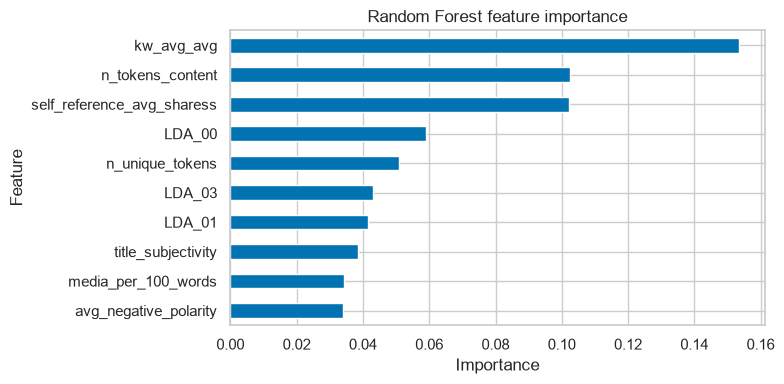

In [24]:
imp = pd.Series(rf.named_steps["model"].feature_importances_, index=names)
imp.nlargest(10).sort_values().plot.barh(figsize=(8, 4))
plt.title("Random Forest feature importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

Average keyword shares, content length, and average shares of referenced articles lead the forest's importance scores. The engineered media-density feature also appears in the top ten. Correlated features can share importance.

## 8. Gradient Boosting

Boosting adds small trees in sequence to reduce the remaining errors. The learning rate controls each tree's contribution.

In [25]:
from sklearn.ensemble import GradientBoostingRegressor

gb = Pipeline([("prep", clone(prep)),
               ("model", GradientBoostingRegressor(n_estimators=100, max_depth=2, random_state=42))])
gb = tune("Gradient Boosting", gb, {"model__learning_rate": [0.03, 0.1]})
evaluate("Gradient Boosting", gb)

,Model,Baseline CV,Tuned CV,Change,Best parameters
0,Gradient Boosting,-0.102035,-0.057581,0.044453,{'model__learning_rate': 0.03}


,Model,R2,RMSE,MAE,Fit seconds
0,Gradient Boosting,-0.074,10335.0982,3059.0818,25.8171


Gradient Boosting gives a test R2 of -0.0740 and an MAE of 3,059 shares. Its squared error is worse than the constant test-mean reference. Tuning changed the mean CV score by +0.04445.

How do the two ensemble methods (Random Forest and Gradient Boosting) compare visually?

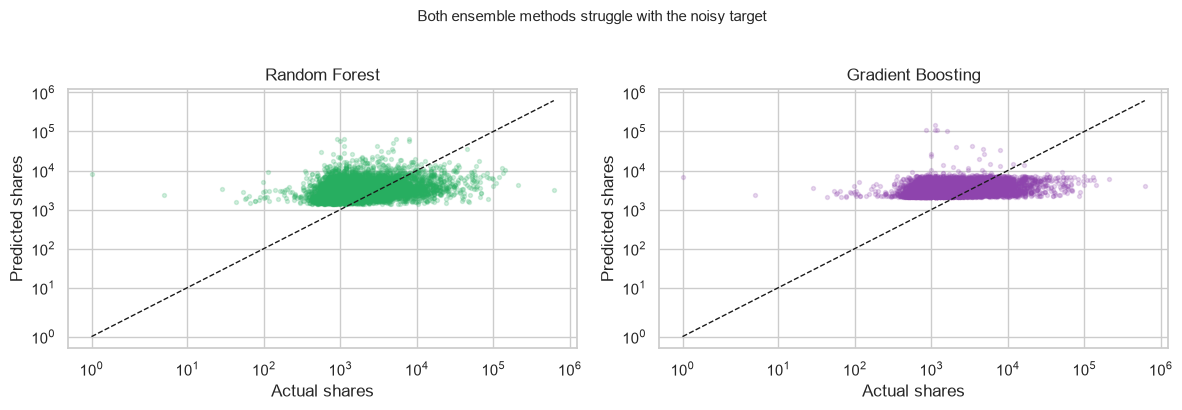

In [26]:
# gradient boosting vs random forest: predicted share distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (name, color) in zip(axes, [("Random Forest", "#27ae60"),
                                      ("Gradient Boosting", "#8e44ad")]):
    pred = predictions[name]
    ax.scatter(y_test, pred, alpha=0.2, s=8, color=color)
    lims = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
    ax.plot(lims, lims, "k--", lw=1)
    ax.set(xscale="symlog", yscale="symlog",
           xlabel="Actual shares", ylabel="Predicted shares", title=name)
plt.suptitle("Both ensemble methods struggle with the noisy target", y=1.02, fontsize=11)
plt.tight_layout()
plt.show()

Gradient Boosting is usually one of the strongest off-the-shelf models, but it also has a negative R2 here. The tuning improvement of +0.04 was the largest across all models, so it was at least finding something in the data. Still, this dataset is really tough for regression.

## 9. SVR

SVR compares linear and RBF kernels. The target is scaled internally to make C and epsilon easier to tune, then predictions are converted back to shares.

In [27]:
from sklearn.svm import SVR
from sklearn.compose import TransformedTargetRegressor

model = TransformedTargetRegressor(regressor=SVR(cache_size=512), transformer=StandardScaler())
svr = Pipeline([("prep", clone(prep)), ("model", model)])
grid = {"model__regressor__C": [1, 10], "model__regressor__kernel": ["linear", "rbf"]}
svr = tune("SVR", svr, grid)
evaluate("SVR", svr)

,Model,Baseline CV,Tuned CV,Change,Best parameters
0,SVR,0.000551,0.000551,0.0,"{'model__regressor__C': 1, 'model__regressor__kernel': 'rbf'}"


,Model,R2,RMSE,MAE,Fit seconds
0,SVR,0.0057,9943.9714,2424.0055,87.9803


SVR gives a test R2 of 0.0057 and an MAE of 2,424 shares. Tuning changed the mean CV score by +0.00000.

SVR had the best MAE. Let's see what its predictions actually look like.

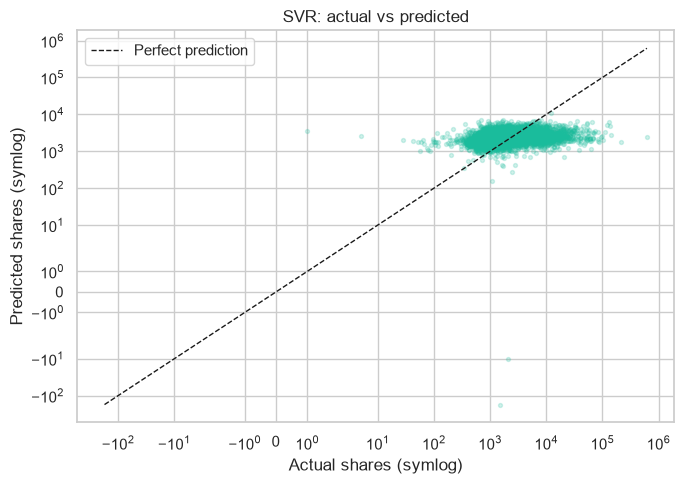

In [28]:
# SVR actual vs predicted
fig, ax = plt.subplots(figsize=(7, 5))
pred_svr = predictions["SVR"]
ax.scatter(y_test, pred_svr, alpha=0.2, s=8, color="#1abc9c")
lims = [min(y_test.min(), pred_svr.min()), max(y_test.max(), pred_svr.max())]
ax.plot(lims, lims, "k--", lw=1, label="Perfect prediction")
ax.set(xscale="symlog", yscale="symlog",
       xlabel="Actual shares (symlog)", ylabel="Predicted shares (symlog)",
       title="SVR: actual vs predicted")
ax.legend()
plt.tight_layout()
plt.show()

SVR has the lowest MAE of all models at 2,424 shares. It's interesting that SVR struggles with R2 but wins on MAE. That's because R2 penalizes big errors heavily (it uses squared error), and SVR with its epsilon-insensitive loss doesn't chase outliers as much. If we care about typical prediction error rather than catching viral articles, SVR is actually the most useful.

## 10. KNN

KNN averages the targets of nearby training rows. Larger k values give smoother predictions.

In [29]:
from sklearn.neighbors import KNeighborsRegressor

knn = Pipeline([("prep", clone(prep)), ("model", KNeighborsRegressor(n_neighbors=15, n_jobs=2))])
knn = tune("KNN", knn, {"model__n_neighbors": [15, 40, 80]})
evaluate("KNN", knn)

,Model,Baseline CV,Tuned CV,Change,Best parameters
0,KNN,-0.014066,0.013563,0.027629,{'model__n_neighbors': 80}


,Model,R2,RMSE,MAE,Fit seconds
0,KNN,0.0074,9935.4225,2863.8984,0.1176


KNN gives a test R2 of 0.0074 and an MAE of 2,864 shares. Tuning changed the mean CV score by +0.02763.

And here's KNN's take on the same test set.

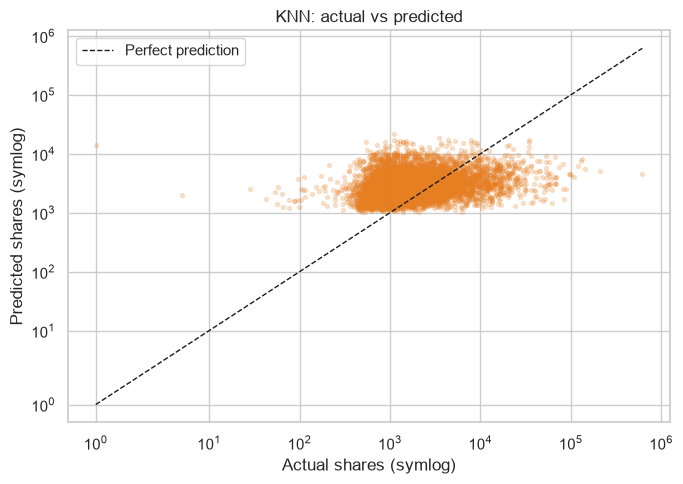

In [30]:
# KNN actual vs predicted
fig, ax = plt.subplots(figsize=(7, 5))
pred_knn = predictions["KNN"]
ax.scatter(y_test, pred_knn, alpha=0.2, s=8, color="#e67e22")
lims = [min(y_test.min(), pred_knn.min()), max(y_test.max(), pred_knn.max())]
ax.plot(lims, lims, "k--", lw=1, label="Perfect prediction")
ax.set(xscale="symlog", yscale="symlog",
       xlabel="Actual shares (symlog)", ylabel="Predicted shares (symlog)",
       title="KNN: actual vs predicted")
ax.legend()
plt.tight_layout()
plt.show()

In [31]:
unscaled = Pipeline([("impute", SimpleImputer(strategy="median")),
                     ("model", clone(knn.named_steps["model"]))])
a = cross_val_score(unscaled, x_tune, y_tune, cv=cv, scoring="r2").mean()
b = cross_val_score(clone(knn), x_tune, y_tune, cv=cv, scoring="r2").mean()
display(pd.DataFrame({"KNN input": ["Unscaled", "Standardized"], "CV R2": [a, b]}))

,KNN input,CV R2
0,Unscaled,0.016308
1,Standardized,0.013563


Unscaled KNN scores 0.0163 in CV, compared with 0.0136 after standardization. Scaling balances feature units, but it does not always improve the score. The same scaled inputs are retained for the ten-model comparison.

It's worth noting that scaling features didn't help KNN here. Sometimes the raw feature magnitudes already capture useful distance information, and normalizing everything squashes that. This is a good reminder to always test both.

## Comparison

,Model,R2,RMSE,MAE,Fit seconds
0,Linear Regression,0.0192,9876.3649,3029.3152,0.1718
1,Ridge,0.0192,9876.4064,3028.7727,0.2963
2,ElasticNet,0.0190,9877.1619,3019.4261,0.5736
3,Lasso,0.0190,9877.4747,3026.6737,0.4834
4,KNN,0.0074,9935.4225,2863.8984,0.1176
5,SVR,0.0057,9943.9714,2424.0055,87.9803
6,Polynomial Regression,0.0043,9951.1293,3208.5829,2.9660
7,Random Forest,-0.0276,10109.4053,3055.3534,70.9719
8,Decision Tree,-0.0580,10257.4436,3085.8039,0.6075
9,Gradient Boosting,-0.0740,10335.0982,3059.0818,25.8171


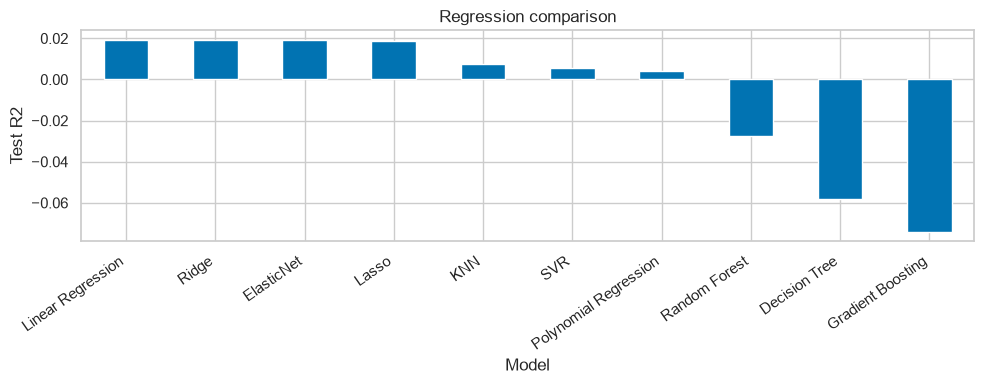

In [32]:
# rank all ten models by R2 and plot the comparison
results = pd.DataFrame(rows).sort_values("R2", ascending=False).reset_index(drop=True)
display(results.round(4))
results.plot.bar(x="Model", y="R2", legend=False, figsize=(10, 4))
plt.title("Regression comparison")
plt.xlabel("Model")
plt.ylabel("Test R2")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

R2 is one way to compare, but MAE and RMSE tell different stories. MAE shows typical error, RMSE punishes big mistakes more.

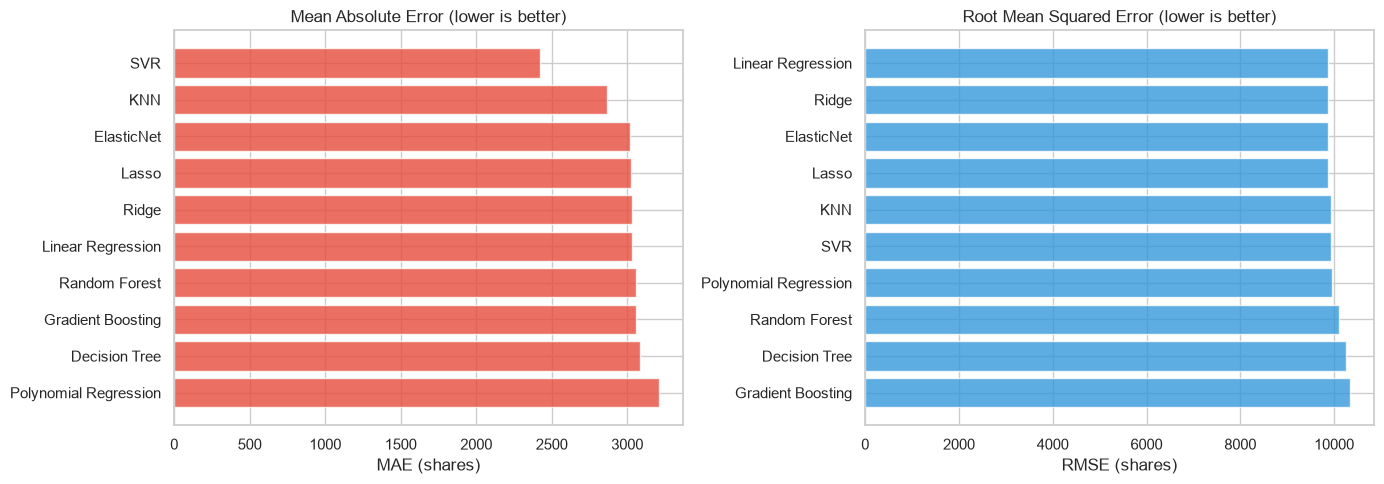

In [33]:
# side-by-side MAE and RMSE comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

results_sorted = results.sort_values("MAE")
axes[0].barh(results_sorted["Model"], results_sorted["MAE"], color="#e74c3c", alpha=0.8)
axes[0].set(xlabel="MAE (shares)", title="Mean Absolute Error (lower is better)")
axes[0].invert_yaxis()

results_sorted2 = results.sort_values("RMSE")
axes[1].barh(results_sorted2["Model"], results_sorted2["RMSE"], color="#3498db", alpha=0.8)
axes[1].set(xlabel="RMSE (shares)", title="Root Mean Squared Error (lower is better)")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

R2 compares squared error with a constant prediction. RMSE gives more weight to large errors, while MAE gives the average absolute error in shares.

Does spending more time training actually give better results? Let's check.

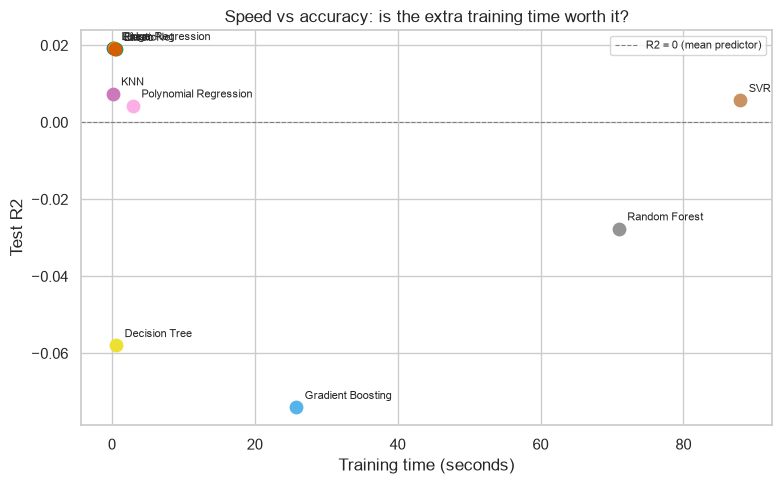

In [34]:
# training time vs R2 scatter to see the speed-accuracy tradeoff
fig, ax = plt.subplots(figsize=(8, 5))
for _, row in results.iterrows():
    ax.scatter(row["Fit seconds"], row["R2"], s=80, zorder=5)
    ax.annotate(row["Model"], (row["Fit seconds"], row["R2"]),
                textcoords="offset points", xytext=(6, 6), fontsize=8)
ax.axhline(0, color="gray", ls="--", lw=0.8, label="R2 = 0 (mean predictor)")
ax.set(xlabel="Training time (seconds)", ylabel="Test R2",
       title="Speed vs accuracy: is the extra training time worth it?")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [35]:
# baseline: predicting the training mean for every test article
pred = np.repeat(y_train.mean(), len(y_test))
display(pd.DataFrame([{"Reference": "Training mean", "R2": r2_score(y_test, pred),
                       "RMSE": root_mean_squared_error(y_test, pred), "MAE": mean_absolute_error(y_test, pred)}]))

,Reference,R2,RMSE,MAE
0,Training mean,-0.000194,9973.474829,3109.142147


The training-mean predictor is a simple reference for the ten models.

This is basically the "do nothing" model. If we just predicted the average share count for every article, we'd get these numbers. Any model worth using should beat this, but as we saw, most of our models actually couldn't.

## Cross-validation

The two leading models are checked with five folds of the full training set. The parameters were chosen using training data, so these CV scores can be optimistic.

In [36]:
# 5-fold CV on the top two models to check stability
top = results["Model"].head(2).tolist()
cv5 = KFold(n_splits=5, shuffle=True, random_state=42)
cv_rows = []
for name in top:
    scores = cross_val_score(clone(fitted[name]), x_train, y_train, cv=cv5, scoring=scoring)
    row = {"Model": name, "CV mean": scores.mean(), "CV std": scores.std()}
    for i, value in enumerate(scores):
        row["Fold " + str(i + 1)] = value
    cv_rows.append(row)
cv_results = pd.DataFrame(cv_rows)
display(cv_results.round(4))

,Model,CV mean,CV std,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5
0,Linear Regression,0.0190,0.0074,0.0284,0.0147,0.011,0.0135,0.0276
1,Ridge,0.0191,0.0075,0.0286,0.0146,0.011,0.0136,0.0277


Let's visualize how consistent the top two models are across the five folds.

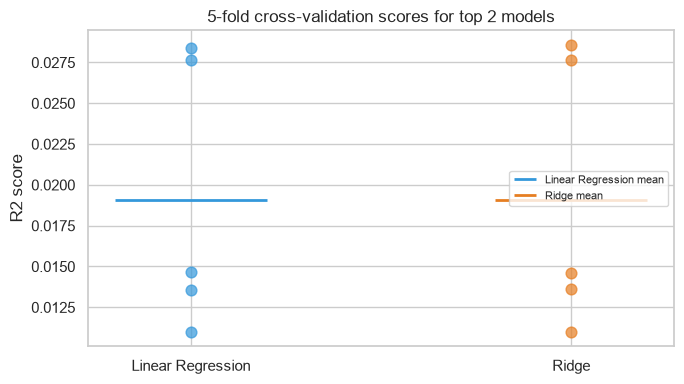

In [37]:
# visualize the 5-fold CV scores for the top two models
fold_cols = [c for c in cv_results.columns if c.startswith("Fold")]
fig, ax = plt.subplots(figsize=(7, 4))
for i, (_, row) in enumerate(cv_results.iterrows()):
    fold_vals = [row[c] for c in fold_cols]
    color = "#3498db" if i == 0 else "#e67e22"
    ax.scatter([row["Model"]] * len(fold_vals), fold_vals, s=60, color=color, zorder=5, alpha=0.7)
    ax.hlines(row["CV mean"], i - 0.2, i + 0.2, color=color, lw=2, label=f'{row["Model"]} mean')
ax.set(ylabel="R2 score", title="5-fold cross-validation scores for top 2 models")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Best model errors

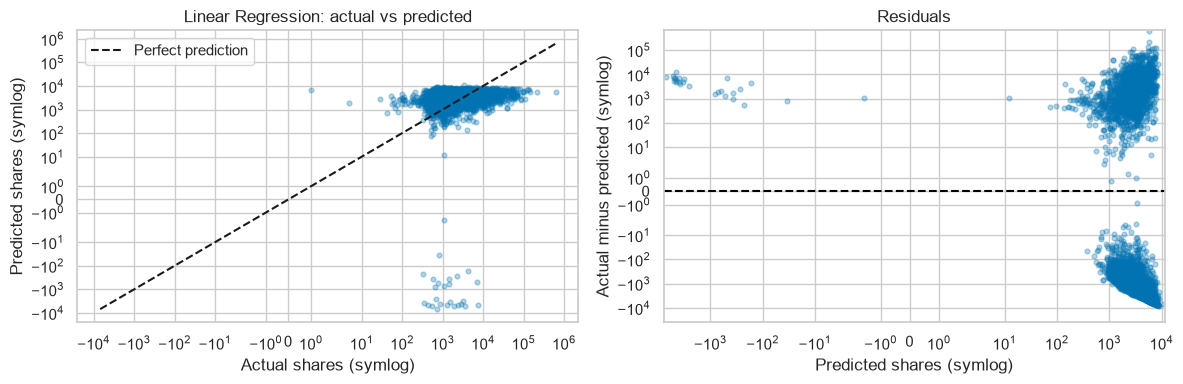

In [38]:
# residual analysis for the best model
best = results.loc[0, "Model"]
pred = predictions[best]
residual = y_test.to_numpy() - pred
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(y_test, pred, alpha=0.3, s=12)
low, high = min(y_test.min(), pred.min()), max(y_test.max(), pred.max())
axes[0].plot([low, high], [low, high], "k--", label="Perfect prediction")
axes[0].set(xscale="symlog", yscale="symlog", title=best + ": actual vs predicted",
            xlabel="Actual shares (symlog)", ylabel="Predicted shares (symlog)")
axes[0].legend()
axes[1].scatter(pred, residual, alpha=0.3, s=12)
axes[1].axhline(0, color="black", linestyle="--")
axes[1].set(xscale="symlog", yscale="symlog", title="Residuals",
            xlabel="Predicted shares (symlog)", ylabel="Actual minus predicted (symlog)")
plt.tight_layout()
plt.show()

Predictions stay in a much narrower range than actual shares, so viral articles are underpredicted. Some linear predictions are negative, which is a limitation for a count target. The symmetric log axes show these values, and the metrics use all predictions without clipping.

The actual vs predicted plot really shows the problem. Our best model's predictions cluster in a narrow band around the mean, while actual shares range from near zero to hundreds of thousands. The model essentially learned to predict "around average" for everything, which is honestly the safest bet given how noisy this target is.

In [39]:
# save all results to CSV for the final report
results.to_csv("../results/news_comparison.csv", index=False)
pd.DataFrame(tune_rows).to_csv("../results/news_tuning.csv", index=False)
cv_results.to_csv("../results/news_top_two_cv.csv", index=False)

One last look: how do the predicted share distributions compare across all ten models? This shows whether models are playing it safe (clustering near the mean) or being more adventurous.

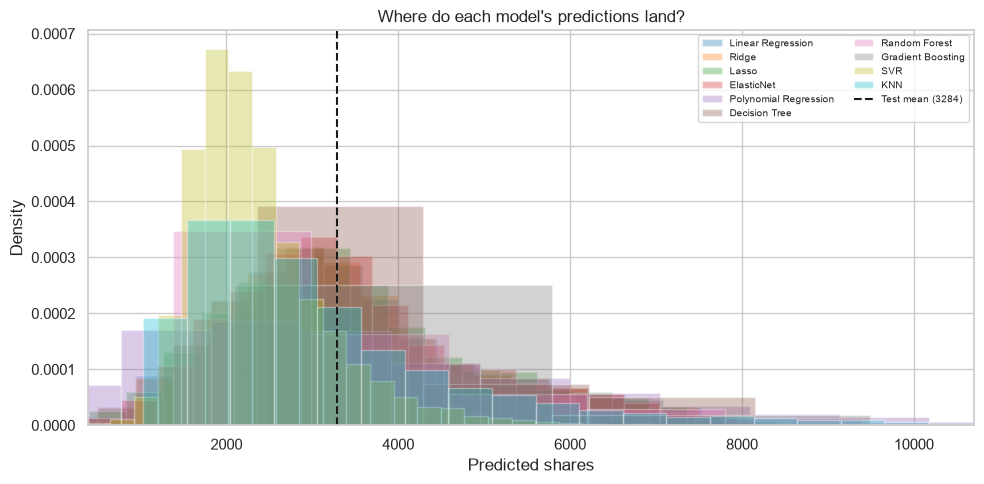

In [40]:
# overlay prediction distributions for all 10 models
fig, ax = plt.subplots(figsize=(10, 5))
colors = plt.cm.tab10(np.linspace(0, 1, 10))
for (name, pred), color in zip(predictions.items(), colors):
    ax.hist(pred, bins=40, alpha=0.35, label=name, color=color, density=True)
ax.axvline(y_test.mean(), color="k", ls="--", lw=1.5, label=f"Test mean ({y_test.mean():.0f})")
ax.set(xlabel="Predicted shares", ylabel="Density",
       title="Where do each model's predictions land?")
ax.legend(fontsize=7, ncol=2)
ax.set_xlim(y_test.quantile(0.01), y_test.quantile(0.95))
plt.tight_layout()
plt.show()

## Conclusion

Linear Regression has the highest test R2 at 0.0192, with RMSE 9,876 and MAE 3,029 shares. Its five-fold R2 is 0.0190 with a standard deviation of 0.0074.

Linear Regression and Ridge are almost tied. SVR has the lowest MAE, so the ranking changes when typical absolute error matters more than large squared errors.

The models explain only a small part of share-count variation. Viral articles are difficult to predict from these metadata features, and they contribute heavily to squared error. Polynomial terms did not improve on the linear baseline. Predictions for individual articles remain unreliable.